Data Cleaning

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Video_Games.csv')

df.head()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Удаляем ненужный индекс
df = df.drop(columns=['index'])

# Удаляем записи без названия и жанра
df = df.dropna(subset=['Name', 'Genre'])

# Преобразуем год
df['Year_of_Release'] = df['Year_of_Release'].astype('Int64')

# Преобразуем User Score
df['User_Score'] = pd.to_numeric(
    df['User_Score'],
    errors='coerce'
)

# Проверяем дубликаты
print('Duplicates:', df.duplicated().sum())

# Проверяем размер после очистки
print('Shape:', df.shape)

# Проверяем типы данных
df.info()

Duplicates: 209
Shape: (16926, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 16926 entries, 0 to 16927
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16926 non-null  object 
 1   Platform         16926 non-null  object 
 2   Year_of_Release  16653 non-null  Int64  
 3   Genre            16926 non-null  object 
 4   Publisher        16871 non-null  object 
 5   NA_Sales         16926 non-null  float64
 6   EU_Sales         16926 non-null  float64
 7   JP_Sales         16926 non-null  float64
 8   Other_Sales      16926 non-null  float64
 9   Global_Sales     16926 non-null  float64
 10  Critic_Score     8260 non-null   float64
 11  Critic_Count     8260 non-null   float64
 12  User_Score       7718 non-null   float64
 13  User_Count       7718 non-null   float64
 14  Developer        10240 non-null  object 
 15  Rating           10092 non-null  object 
dtypes: Int64(1), float64(9), obj

В ходе предварительной обработки были выявлены пропущенные значения в годе выпуска, оценках пользователей и критиков, издателях, разработчиках и возрастных рейтингах.

Строки без названия игры и жанра были удалены. Пропущенные оценки не заменялись средними значениями, поскольку искусственное заполнение могло исказить результаты анализа. Для анализа оценок использовались только записи, содержащие соответствующие значения.

User_Score был преобразован из текстового в числовой формат, при этом нечисловые значения были преобразованы в пропуски.

# Exploratory Data Analysis (EDA)

Цель анализа — определить, какие характеристики видеоигр связаны
с их коммерческим успехом.

В качестве основного показателя коммерческого успеха используется
Global_Sales — мировые продажи игры в миллионах копий.

In [42]:
total_games = df['Name'].nunique()
total_sales = df['Global_Sales'].sum()
avg_critic_score = df['Critic_Score'].mean()
avg_user_score = df['User_Score'].mean()

print(f'Количество игр: {total_games}')
print(f'Мировые продажи: {total_sales:.2f} млн копий')
print(f'Средняя оценка критиков: {avg_critic_score:.1f}')
print(f'Средняя оценка пользователей: {avg_user_score:.1f}')

Количество игр: 11562
Мировые продажи: 9130.58 млн копий
Средняя оценка критиков: 69.0
Средняя оценка пользователей: 7.1


## Анализ продаж по жанрам

На данном этапе исследуется распределение мировых продаж между
различными жанрами видеоигр.

In [43]:
genre_sales = (
    df.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

genre_sales

,Global_Sales
Genre,
Action,1771.73
Sports,1350.61
Shooter,1086.67
Role-Playing,958.62
Platform,850.73
Misc,830.19
Racing,757.92
Fighting,467.91
Simulation,394.12


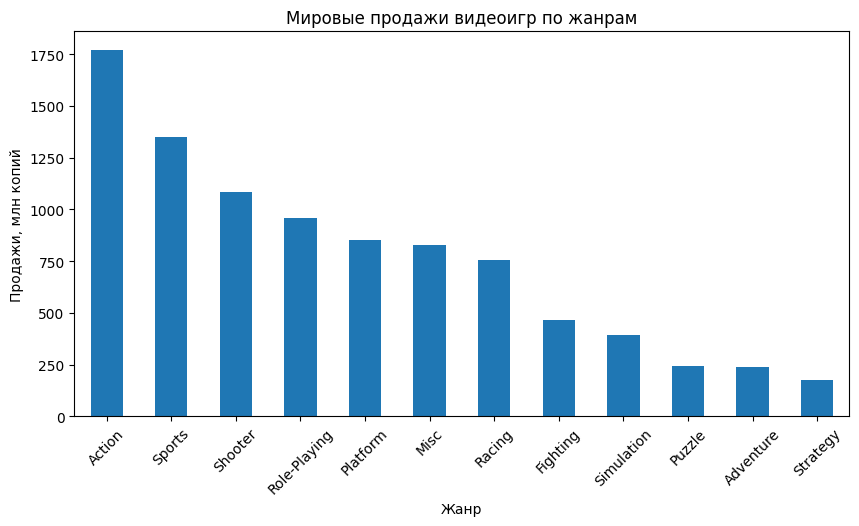

In [44]:
genre_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Мировые продажи видеоигр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Продажи, млн копий')
plt.xticks(rotation=45)
plt.show()

In [45]:
genre_count = (
    df.groupby('Genre')['Name']
    .count()
    .sort_values(ascending=False)
)

genre_count

,Name
Genre,
Action,3410
Sports,2380
Misc,1773
Role-Playing,1519
Shooter,1347
Adventure,1313
Racing,1266
Platform,904
Simulation,880


In [46]:
genre_avg_sales = (
    df.groupby('Genre')['Global_Sales']
    .mean()
    .sort_values(ascending=False)
)

genre_avg_sales

,Global_Sales
Genre,
Platform,0.941073
Shooter,0.806733
Role-Playing,0.631086
Racing,0.598673
Sports,0.567483
Fighting,0.542190
Action,0.519569
Misc,0.468240
Simulation,0.447864


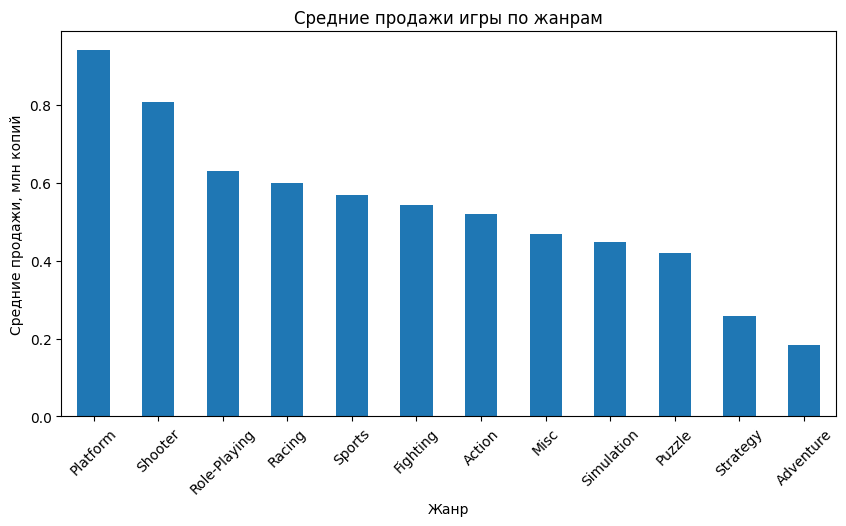

In [47]:
genre_avg_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Средние продажи игры по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Средние продажи, млн копий')
plt.xticks(rotation=45)
plt.show()

### Вывод

По совокупным мировым продажам лидирует жанр **Action** — около 1772 млн копий.
Следом идут **Sports** и **Shooter**.

Однако по средним продажам одной игры лидирует **Platform** — около 0.94 млн копий,
а второе место занимает **Shooter** — около 0.81 млн.

Таким образом, высокий общий объем продаж жанра не обязательно означает,
что отдельная игра этого жанра в среднем продается лучше. Например, Action
лидирует по общим продажам, но занимает более низкую позицию по средним продажам.

## Анализ продаж по платформам

Рассмотрим, на каких игровых платформах наблюдались наибольшие мировые продажи.
Для сравнения используются совокупные и средние продажи игр.

In [48]:
platform_sales = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

platform_sales

,Global_Sales
Platform,
PS2,1283.08
X360,988.36
PS3,962.71
Wii,937.27
DS,813.86
PS,759.88
GBA,327.11
PS4,324.48
PSP,298.02


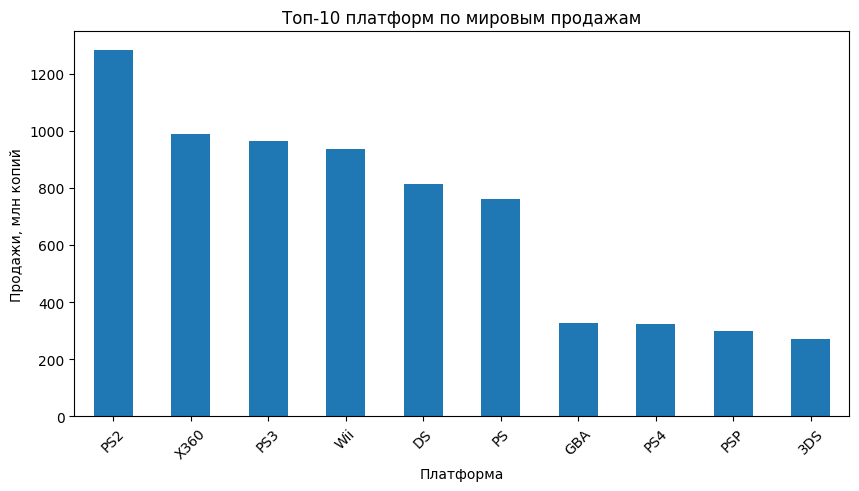

In [49]:
platform_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Топ-10 платформ по мировым продажам')
plt.xlabel('Платформа')
plt.ylabel('Продажи, млн копий')
plt.xticks(rotation=45)
plt.show()

In [50]:
platform_avg_sales = (
    df.groupby('Platform')['Global_Sales']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

platform_avg_sales

,Global_Sales
Platform,
GB,2.586566
NES,2.561939
GEN,1.050370
SNES,0.834380
PS4,0.813233
X360,0.772156
2600,0.727574
PS3,0.708396
Wii,0.701025


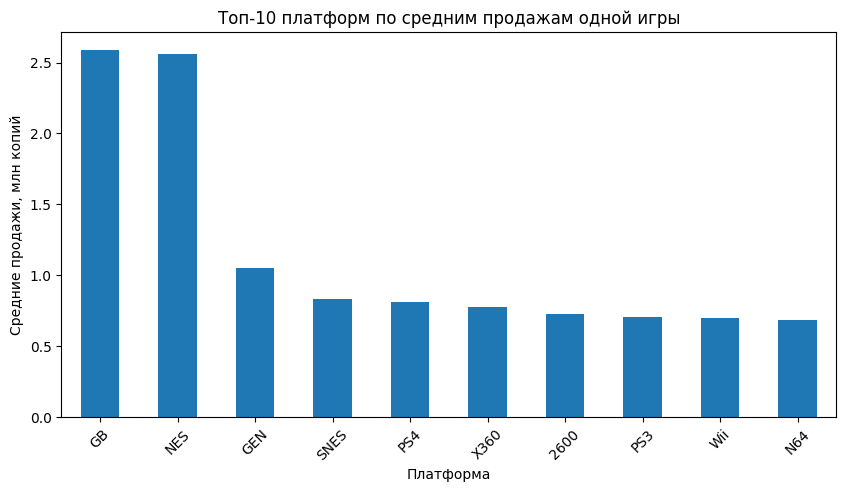

In [51]:
platform_avg_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Топ-10 платформ по средним продажам одной игры')
plt.xlabel('Платформа')
plt.ylabel('Средние продажи, млн копий')
plt.xticks(rotation=45)
plt.show()

### Вывод

По совокупным мировым продажам лидирует **PlayStation 2 (PS2)** — около 1283 млн копий.
Далее следуют **Xbox 360 (X360)** — 988 млн и **PlayStation 3 (PS3)** — 963 млн.

При расчете средних продаж одной игры результаты отличаются. Наибольшие значения
наблюдаются у **Game Boy (GB)** — около 2.59 млн копий и **NES** — около 2.56 млн.

Таким образом, платформы с крупнейшими совокупными продажами не обязательно имеют
наибольшие средние продажи одной игры. При этом результаты средних продаж следует
интерпретировать осторожно, поскольку количество выпущенных игр и периоды активности
платформ различаются.

## Динамика рынка видеоигр

Рассмотрим, как менялись мировые продажи видеоигр по годам.
Это позволит определить основные периоды роста и снижения рынка
в рамках представленных данных.

In [52]:
year_sales = (
    df.groupby('Year_of_Release')['Global_Sales']
    .sum()
    .sort_index()
)

year_sales

,Global_Sales
Year_of_Release,
1980,11.38
1981,35.77
1982,30.73
1983,16.79
1984,50.36
1985,53.94
1986,37.07
1987,21.74
1988,47.22


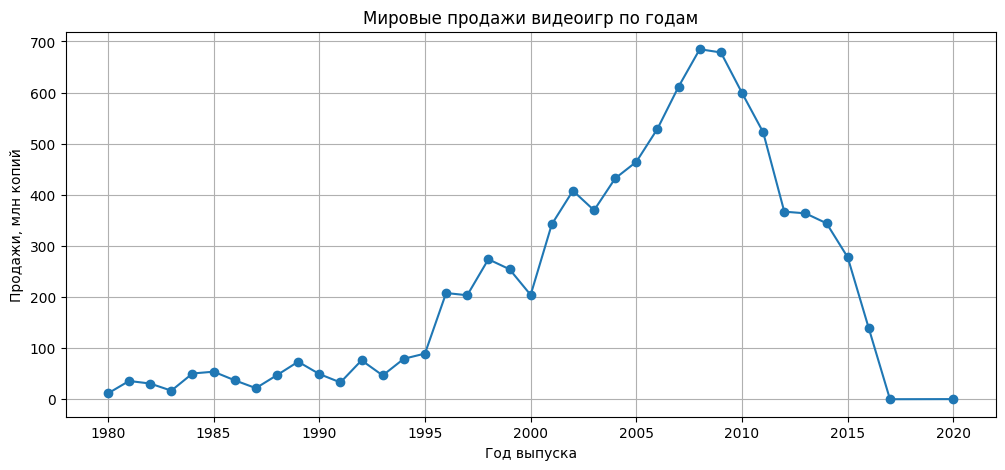

In [53]:
year_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Мировые продажи видеоигр по годам')
plt.xlabel('Год выпуска')
plt.ylabel('Продажи, млн копий')
plt.grid(True)
plt.show()

In [54]:
games_by_year = (
    df.groupby('Year_of_Release')['Name']
    .count()
    .sort_index()
)

games_by_year

,Name
Year_of_Release,
1980,9
1981,46
1982,39
1983,17
1984,14
1985,14
1986,21
1987,16
1988,15


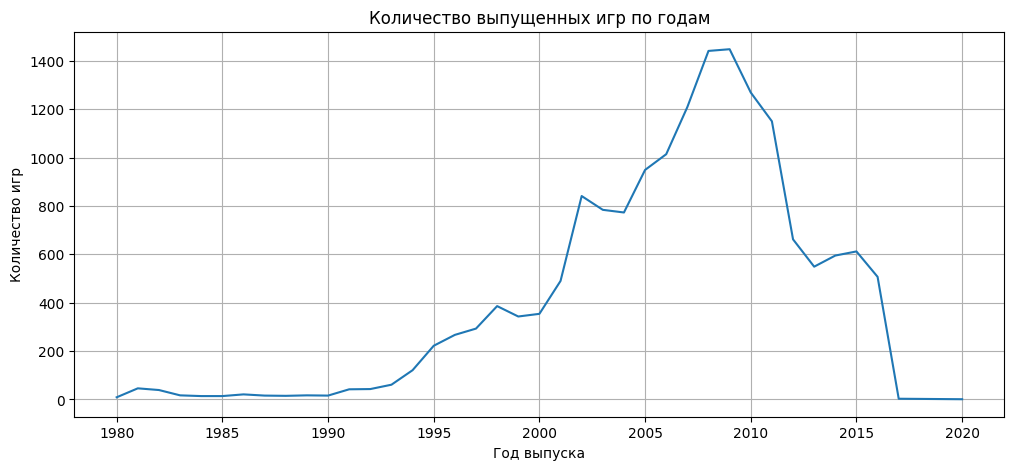

In [55]:
games_by_year.plot(
    kind='line',
    figsize=(12, 5)
)

plt.title('Количество выпущенных игр по годам')
plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.grid(True)
plt.show()

In [56]:
print('Год с максимальными продажами:')
print(year_sales.idxmax(), '-', round(year_sales.max(), 2), 'млн копий')

print('\nГод с наибольшим количеством игр:')
print(games_by_year.idxmax(), '-', games_by_year.max(), 'игр')

Год с максимальными продажами:
2008 - 684.76 млн копий

Год с наибольшим количеством игр:
2009 - 1448 игр


### Вывод

Наибольший объем мировых продаж в датасете наблюдается в **2008 году** —
около **684.76 млн копий**.

При этом максимальное количество игр было выпущено в **2009 году** —
**1448 игр**.

Таким образом, увеличение количества выпущенных игр не обязательно приводит
к пропорциональному росту совокупных продаж. Пик продаж был достигнут раньше,
чем пик количества релизов.

## Связь оценок критиков с продажами

Проверим, существует ли связь между оценкой игры профессиональными критиками
и ее мировыми продажами.

In [57]:
critic_data = df[['Critic_Score', 'Global_Sales']].dropna()

critic_data.head()

,Critic_Score,Global_Sales
0,76.0,82.53
2,82.0,35.52
3,80.0,32.77
6,89.0,29.80
7,58.0,28.92


In [58]:
critic_corr = critic_data['Critic_Score'].corr(
    critic_data['Global_Sales']
)

print(f'Корреляция между оценкой критиков и продажами: {critic_corr:.3f}')

Корреляция между оценкой критиков и продажами: 0.247


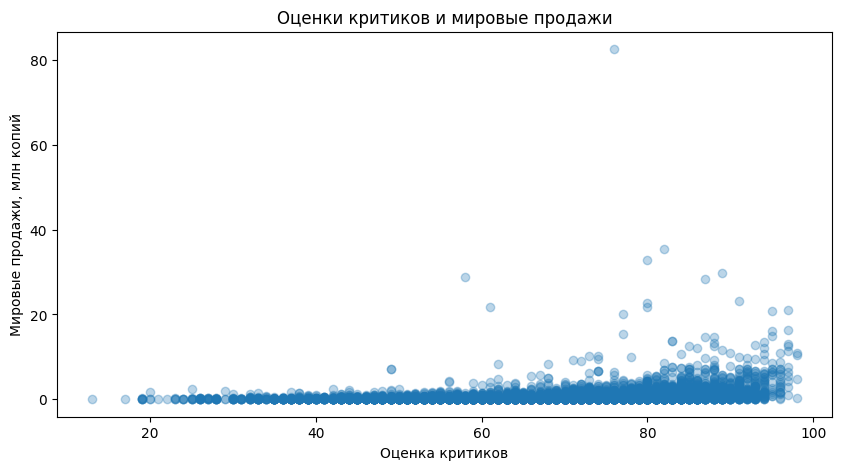

In [59]:
plt.figure(figsize=(10, 5))

plt.scatter(
    critic_data['Critic_Score'],
    critic_data['Global_Sales'],
    alpha=0.3
)

plt.title('Оценки критиков и мировые продажи')
plt.xlabel('Оценка критиков')
plt.ylabel('Мировые продажи, млн копий')
plt.show()

## Связь оценок пользователей с продажами

Также проверим, существует ли связь между пользовательскими оценками
и мировыми продажами видеоигр.

In [60]:
user_data = df[['User_Score', 'Global_Sales']].dropna()

user_corr = user_data['User_Score'].corr(
    user_data['Global_Sales']
)

print(f'Корреляция между оценкой пользователей и продажами: {user_corr:.3f}')

Корреляция между оценкой пользователей и продажами: 0.091


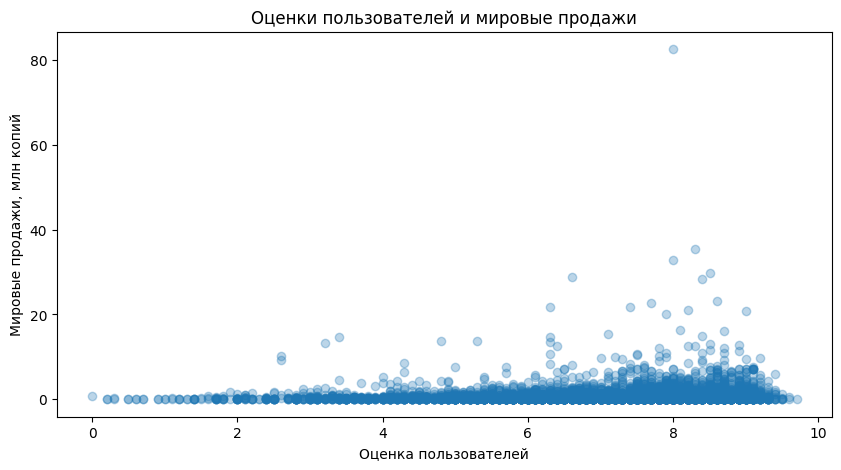

In [61]:
plt.figure(figsize=(10, 5))

plt.scatter(
    user_data['User_Score'],
    user_data['Global_Sales'],
    alpha=0.3
)

plt.title('Оценки пользователей и мировые продажи')
plt.xlabel('Оценка пользователей')
plt.ylabel('Мировые продажи, млн копий')
plt.show()

### Вывод

Между оценками критиков и мировыми продажами наблюдается слабая положительная
корреляция (**r = 0.247**). Это означает, что игры с более высокими оценками
критиков в среднем склонны иметь более высокие продажи, однако связь является слабой.

Для пользовательских оценок корреляция еще ниже (**r = 0.091**), что указывает
на очень слабую линейную связь между User Score и мировыми продажами.

Таким образом, высокие оценки сами по себе не являются сильным индикатором
коммерческого успеха игры. На продажи могут быть связаны и другие факторы,
такие как жанр, платформа, популярность франшизы, маркетинг и период выпуска.

При этом корреляция показывает наличие связи, но не доказывает
причинно-следственную зависимость.

## Региональные различия в продажах

Рассмотрим, какие жанры видеоигр имеют наибольшие продажи в Северной Америке,
Европе и Японии. Это позволит определить различия в предпочтениях между регионами.

In [62]:
regional_genre_sales = (
    df.groupby('Genre')[
        ['NA_Sales', 'EU_Sales', 'JP_Sales']
    ]
    .sum()
)

regional_genre_sales

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,893.89,526.25,163.51
Adventure,106.06,64.12,53.22
Fighting,233.86,104.87,91.83
Misc,421.86,220.73,109.36
Platform,457.00,207.10,133.83
Puzzle,122.88,50.01,57.93
Racing,373.12,246.78,59.19
Role-Playing,338.81,194.68,363.56
Shooter,608.07,329.20,40.64


In [63]:
print('Самый продаваемый жанр в Северной Америке:')
print(regional_genre_sales['NA_Sales'].idxmax())

print('\nСамый продаваемый жанр в Европе:')
print(regional_genre_sales['EU_Sales'].idxmax())

print('\nСамый продаваемый жанр в Японии:')
print(regional_genre_sales['JP_Sales'].idxmax())

Самый продаваемый жанр в Северной Америке:
Action

Самый продаваемый жанр в Европе:
Action

Самый продаваемый жанр в Японии:
Role-Playing


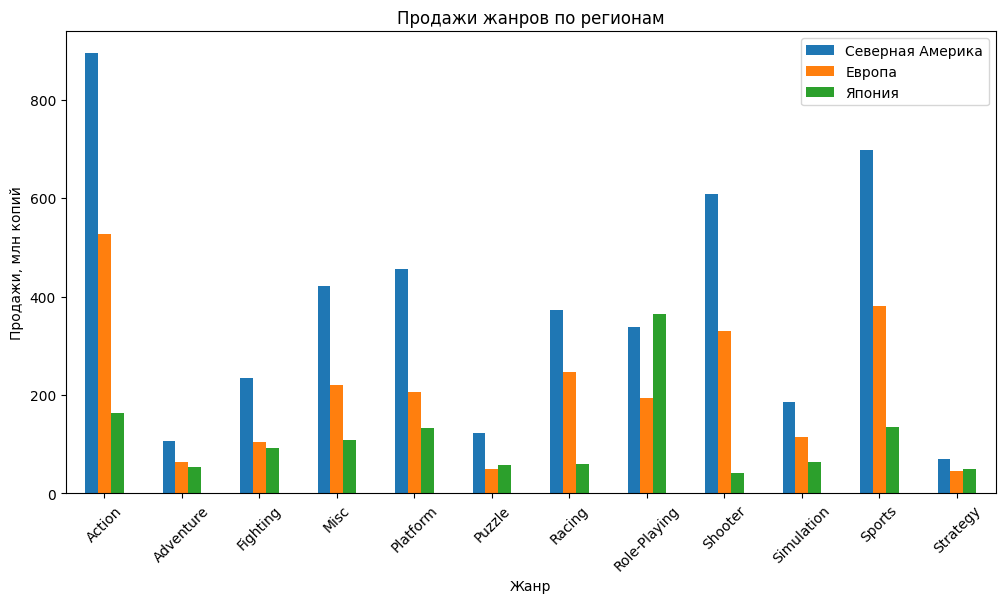

In [64]:
regional_genre_sales.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Продажи жанров по регионам')
plt.xlabel('Жанр')
plt.ylabel('Продажи, млн копий')
plt.xticks(rotation=45)
plt.legend(['Северная Америка', 'Европа', 'Япония'])
plt.show()

### Вывод

Региональный анализ показал различия в предпочтениях между рынками.

В **Северной Америке** и **Европе** наибольший объем продаж приходится на жанр **Action**.
В **Японии** лидирует жанр **Role-Playing**.

Это показывает, что популярность жанров различается в зависимости от региона.
Поэтому при оценке потенциального рынка видеоигры важно учитывать не только
глобальные продажи, но и региональные особенности спроса.